# Cavity model in co-simulation

The following is to describe a RF cavity from the control system point of view, using the textbook terms of linear, time invariant systems in feedback loops, and try to associate with conventional cavity equation in accelerator engineering.

## RF Band

The RF cavity can be modeled as a general second order dynamic system, or a
band pass filter, with a possible non-zero initial state.  The transfer function
of the cavity in Laplace domain is:

$$
H(s) = \frac{2\alpha s}{s^2 + 2\alpha s + \omega_0^2}
$$

where $\alpha$ is the attenuation factor, $\omega_0$ is the central
resonance frequency.  In this case the system is
under-damped since the damping ratio $\zeta = \frac{\alpha}{\omega_0} \ll
1$, so $H(s)$ has two conjugate poles at the left half of s-plane, located
at $\lambda_{1,2}$, very close to imaginary axis.

* Zeros
  
  $$
  s_0 = 0
  $$

* Poles

  $$
  \lambda_{1,2} = -\alpha \pm j \sqrt{\omega_0^2-\alpha^2}, \quad
  \zeta = \frac{1}{\omega_0\tau} = \frac{1}{2Q}
  $$
  where $\sqrt{\omega_0^2-\alpha^2}$ is also known as the damped natural frequency in control theory.
  The full bandwidth ([3dB bandwidth](https://en.wikipedia.org/wiki/Bandwidth_(signal_processing)#x_dB_bandwidth)) of the cavity is measured between the 3dB points of its magnitude response,
  which could be calculated as:
  $$
  \Delta\omega = 2\alpha = \frac{2}{\tau} = \frac{\omega_0}{Q}
  $$
  The real part of the poles $-\alpha$ determines the damping of the system, which affects the bandwidth of the filter.
  The imaginary part $\sqrt{\omega_0^2-\alpha^2}$ determines the resonant frequency.

Note that the time constant calculated by the decay of $P(t)$ is
$\tau_\text{p} = \frac{1}{2}\tau$ since $P(t)\propto V^2(t)$.


## Base Band

Mathematically this process shift the frequency components of the signal by $-\omega_0$, and we substitute $s$ with $s+j\omega_0$ in the transfer function.

So the band pass filter becomes a low pass filter with transfer function after
the down-converter to IF:

$$
H_\text{base}(s) = H(s + j\omega_0) = \frac{2\alpha \cdot (s + j\omega_0)}{s^2 + 2(j\omega_0 + \alpha)s + 2j\alpha \omega_0}
$$

* Zeros
  
  $$
  s_0 = -j\omega_0
  $$

* Poles
  
  $$
  \lambda_{1,2} = -\alpha + j \left( -\omega_0 \pm \sqrt{\omega_0^2 - \alpha^2} \right)
  $$

### Approximation for high Q cavity

The real part of the poles $-\alpha$ determines the damping (or pass bandwidth) of the system.
The imaginary part of poles indicates the resonance frequency, which are located at sum and difference frequencies.

For high-Q cavities and measurement frequencies $\omega$ near $\omega_0$, we can ignore the effect of the high frequency pole and high frequency zero.
If we define the cavity detune frequency as:

$$
\omega_d = \sqrt{\omega_0^2 - \alpha^2} - \omega_0
$$

The approximated base-band transfer function is:

$$
H_\text{base}(s) \simeq \frac{2\alpha}{s - (-\alpha + j \omega_d)}
$$

In case of studying non-zero state system response, we can re-write this to a first order differential equation in general case:

$$
\frac{\text{d}y(t)}{\text{d}t} - (-\alpha + \jmath\omega_{d})y(t) = 2\alpha\cdot u(t)
$$

where $u(t)$ is the drive signal, $y(t)$ is the output signal (or cavity voltage), in volts.  

## Cross check

<!-- The extended equations for cavity analysis are summarized as below:

\begin{align*}
Q_\text{L} &= \frac{\omega_0}{\Delta\omega} = 4\pi f_0 \tau = 2\pi f_0 \tau_\text{p} \\
\tau & = \frac{2}{\Delta\omega} = \frac{1}{2\pi f_{1/2}} \\
U & = \int_0^\infty P_\text{r}(t) \text{d} t
    = \int_0^\infty P_\text{r}(t_0)e^{-\frac{t}{\tau_\text{p}}} \text{d} t
    = P_\text{r}(t_0)\cdot\tau_\text{p} \\
E & = \sqrt{2\pi f_0 U \cdot \frac{r/Q}{L}} \\
Q_\text{FP} &= \frac{E^2}{P_\text{TRAN}}\cdot \frac{L}{r/Q} \\
\frac{1}{Q_L} & = \frac{1}{Q_0} + \frac{1}{Q_\text{FP}} +\frac{1}{Q_\text{FPC}} = \frac{1}{Q_0} + \frac{1}{Q_e}
\end{align*} -->


In accelerator text book, the cavity equation is (29) in [1](https://accelconf.web.cern.ch/SRF2005/papers/sup02.pdf):

$$
\left(1 - j\frac{\omega_{d}}{\omega_f}\right)\vec{E} + \frac{1}{\omega_f}\frac{d\vec{E}}{dt}
= 2\vec{K}\sqrt{\frac{R_C}{L}} - R_C\vec{I}
$$

where $\vec{K}$ is the incident wave amplitude in the unit of $\sqrt{\text{watt}}$, $\omega_{d}$ is the (time varying) detune angle, $\vec{E}$ is electric field in $m$, $R_C=Q_L(r/Q)$ in $\Omega / m$, $L$ is electrical length in $m$, and $\omega_f = \omega_0 / 2Q_L$, and $\vec{I}$ is beam current.

Without beam, i.e. $\vec{I}=0$, the two differential equations are equivalent if considering the cavity coupling factors, i.e. $u(t) = \vec{K}\sqrt{\frac{R_C}{L}}$. And obviously the attenuation factor $\alpha$ is equivalent to $\omega_f$.


## IF Band

The LLRF sees the signal at intermediate frequency (IF) band, where the analog frontend down-converts the cavity signal with the local oscillator frequency
$\omega_\text{LO}$ to $\omega_\text{IF} = \omega_0 - \omega_\text{LO}$.

This is equivalent to the transfer function of a bandpass filter with resonance frequency at $\omega_\text{IF}$:

$$
H_\text{IF}(s) = \frac{2\alpha s}{s^2 + 2\alpha s + \omega_\text{IF}^2}
$$

For co-simulation with a digital controller with sampling rate of $F_s = 1/T$, the transfer function can be translated in $Z$ domain using [bilinear transform](https://en.wikipedia.org/wiki/Bilinear_transform) to get $H_\text{IF}(z)$:

$$
s = \frac{2}{T} \cdot \frac{1-z^{-1}}{1+z^{-1}}
$$

and substitute into $H_\text{IF}(s)$, where the non linear relationship ([frequency warping](https://en.wikipedia.org/wiki/Bilinear_transform#Frequency_warping)) should be taken care of by prewarping the resonant frequency, by:

$$
\omega_\text{IF, warped} = \frac{2}{T} \tan \left( \omega_\text{IF} \frac{T}{2} \right)
$$

This non linear frequency warping will also result in a distortion of the filter's 3dB bandwidth, which grows by a [factor](https://www.w3.org/TR/audio-eq-cookbook/) of:

$$
\frac{\Delta_{\omega, \text{warped}}}{\Delta_\omega} \approx \frac{\sin(\omega_\text{IF, warped})}{\omega_\text{IF, warped}}
$$

where the proof can be found [here](https://dsp.stackexchange.com/questions/32196/prewarping-both-resonant-frequency-f-0-and-bandwidth-or-q-when-using-bilin).

Both the center frequency and bandwidth need to be adjusted when using the bilinear transform, in order to have an accurate representation of the cavity model in discrete time domain.

The resulting digital IIR bandpass filter (discrete LTI system) can be plugged in the feedback simulation.

<!-- This process shifts the center frequency by $-\omega_\text{LO}$, and we substitute $s$ with $s + j\omega_\text{LO}$ in $H(s)$ in the resulting transfer function.

$$
H_{\text{IF}}(s) = H(s + j\omega_\text{LO}) = \frac{2\alpha (s + j\omega_\text{LO})}{(s + j\omega_\text{LO})^2 + 2\alpha(s + j\omega_\text{LO}) + \omega_0^2} 
= \frac{2\alpha \cdot (s + j\omega_\text{LO})}{s^2 + 2(j\omega_\text{LO} + \alpha)s + \omega_0^2 - \omega_\text{LO}^2 + 2\alpha j \omega_\text{LO}}
 \tag{3}
$$

This transfer function describes a band-pass filter that has been shifted to an intermediate frequency $\omega_\text{IF}$.
The form of the transfer function remains a band-pass filter but centered at the new frequency $\omega_\text{IF}$.

The zero and poles are also shifted by $\omega_\text{LO}$:

* Zeros

    $$
    s_0 = -j\omega_\text{LO}
    $$

* Poles

    $$
    \lambda_{1,2} = -\alpha + j \left( -\omega_\text{LO} \pm \sqrt{\omega_0^2 - \alpha^2} \right)
    $$ -->
<!-- ### Approximation for high Q cavity

Similar to base-band case, only the low frequency component of the system is considered.

$$
H_\text{IF}(s) \simeq \frac{2\alpha}{s - \left(-\alpha + j \left( \sqrt{\omega_0^2 - \alpha^2} - \omega_\text{LO} \right)\right)} \simeq \frac{2\alpha}{s - (-\alpha + j \omega_\text{IF})},
 \qquad \text{if} \quad \alpha \ll \omega_0
 \tag{4}
$$ -->

# Cavity in simulation

Model cavity in IF band where LLRF digitizers are directly operating at.
Create discrete LTI model using $H_\text{IF}(z)$.

In [1]:
import json
import matplotlib.pyplot as plt
import numpy as np
from scipy import signal

plt.rcParams['figure.figsize'] = [6, 4]
plt.rcParams['axes.grid'] = True
plt.rcParams['axes.grid.which'] = "both"
plt.rcParams['grid.linewidth'] = 0.5
plt.rcParams['grid.alpha'] = 0.5
plt.rcParams['font.size'] = 8

## Load ALSU Cavity Parameters

In [2]:
def plot_freqresp(f, h, fs=1, f0_exp=0):
    fig, axes = plt.subplots(2, sharex=True)
    fig.suptitle('Frequency Response of Cavity')
    axes[0].semilogy(f, np.abs(h))
    axes[0].set_ylabel('Magnitude')
    axes[1].plot(f, np.unwrap(np.angle(h)))
    axes[1].set_ylabel('Phase [rad]')
    axes[-1].set_xlabel('Freq [MHz]')

def verify_freq(f, h, f0_exp, B):
    print(f'Measured center freq:   {f[np.argmax(np.abs(h))]:8.3f} MHz, expected: {f0_exp / 1e6:8.3f} MHz')

    pass_band = f[np.abs(h) > np.sqrt(.5)]
    bandwidth = pass_band[-1] - pass_band[0]

    print(f'Measured 3dB bandwidth: {bandwidth * 1e3:8.3f} kHz, expected: {B / 2 / np.pi / 1e3:8.3f} kHz')
    if True:
        kk = np.nonzero(np.abs(h) > np.sqrt(.5))[0]
        print("curve-fitting with %d points" % len(kk))
        pass_gain = 1.0/abs(h[kk])**2
        ff = np.polyfit(pass_band, pass_gain, 2)
        f0 = -ff[1]/(2*ff[0])
        a0 = np.polyval(ff, f0)
        b0 = 2.0/np.sqrt(ff[0])  # 2.0 for full-bandwidth
        print(f'Measured center freq:   {f0:8.3f} MHz, expected: {f0_exp / 1e6:8.3f} MHz')
        print(f'Measured 3dB bandwidth: {b0 * 1e3:8.3f} kHz, expected: {B / 2 / np.pi / 1e3:8.3f} kHz')
        print(f'Measured center gain:   {1/a0**2:8.3f}')

In [3]:
with open('cavity.json') as f:
    configs = json.load(f)

config = configs['ALSU']
Q0 = config['Q0']
f0 = config['f0']
beta = config['beta']
Ql = Q0 / (1 + beta)
alpha = np.pi * f0 / Ql

print(f'Q0: {Q0}, f0: {f0:.0f} Hz, beta: {beta}, alpha: {alpha:.3f} radian/s')

Q0: 15659, f0: 500394000 Hz, beta: 1.18, alpha: 218853.973 radian/s


## RF band continuous time LTI model

In [4]:
B = 2 * alpha  # bandwidth in rad/s
omega_0 = 2 * np.pi * f0  # center frequency in rad / s

num = [B, 0]  # Numerator coefficients [B_warped * s^1, B_warped * s^0]
den = [1, B, omega_0**2]  # Denominator coefficients [s^2, B_warped * s^1, omega_0_warped^2]

system_s = signal.TransferFunction(num, den)

W = 2 * np.pi * np.linspace(f0 * 0.9999, f0 * 1.0001, num=2048)
w, h = system_s.freqresp(W)
f = w / 2 / np.pi / 1e6

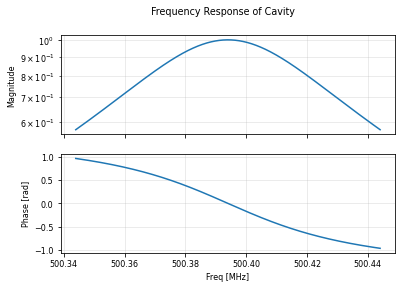

In [5]:
plot_freqresp(f, h)

In [6]:
verify_freq(f, h, f0, B)

Measured center freq:    500.394 MHz, expected:  500.394 MHz
Measured 3dB bandwidth:   69.571 kHz, expected:   69.663 kHz
curve-fitting with 1424 points
Measured center freq:    500.394 MHz, expected:  500.394 MHz
Measured 3dB bandwidth:   69.663 kHz, expected:   69.663 kHz
Measured center gain:      1.000


## IF band discrete time LTI model

In [7]:
from llrf_model import LLRFModel

model = LLRFModel(conf='ALSU')

fs = 1e9 / model.DSP_CLK_CYCLE
f_if = model.NUM_DDS / model.DEN_DDS * fs
T = 1 / fs

In [8]:
B = 2 * alpha  # bandwidth in rad/s

omega_0 = 2 * np.pi * f_if  # center frequency in rad / s
omega_norm = omega_0 / fs

# Prewarp the center frequency omega_0
omega_0_warped = 2 * fs * np.tan(omega_norm / 2)
B_warped = B * omega_0_warped / omega_0

# compensate bilinear transform bandwidth
B_warped /= np.sin(omega_norm) / omega_norm

# Create the Transfer Function in the s-domain with Prewarped Parameters
num = [B_warped, 0]  # Numerator coefficients [B_warped * s^1, B_warped * s^0]
den = [1, B_warped, omega_0_warped**2]  # Denominator coefficients [s^2, B_warped * s^1, omega_0_warped^2]

# Convert the transfer function from s-domain to z-domain using bilinear transform
num_z, den_z = signal.bilinear(num, den, fs=fs)

# Create the discrete-time transfer function
system_z = signal.TransferFunction(num_z, den_z, dt=T)

In [9]:
W = 2 * np.pi * np.linspace(f_if / fs * 0.999, f_if / fs * 1.001, num=2048)
w, h = system_z.freqresp(W)
f = w / np.pi / 2 * fs / 1e6  # MHz

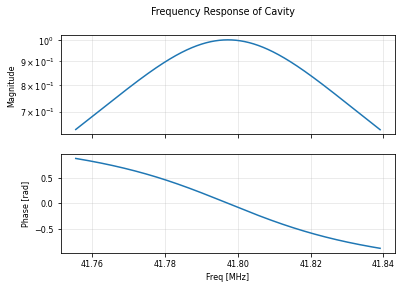

In [10]:
plot_freqresp(f, h)

In [11]:
verify_freq(f, h, f_if, B)

Measured center freq:     41.797 MHz, expected:   41.797 MHz
Measured 3dB bandwidth:   69.628 kHz, expected:   69.663 kHz
curve-fitting with 1706 points
Measured center freq:     41.797 MHz, expected:   41.797 MHz
Measured 3dB bandwidth:   69.663 kHz, expected:   69.663 kHz
Measured center gain:      1.000


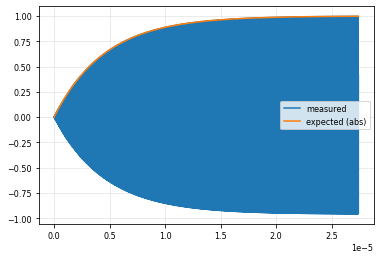

In [12]:
tau = 1 / alpha
t = np.arange(6 * tau  / T) * T
u = np.exp(2j * np.pi * f_if * t)
_, y = signal.dlsim(system_z, u.real)

plt.plot(t, np.squeeze(y), label='measured');
plt.plot(t, 1 - np.exp(-t / tau), label='expected (abs)');
plt.legend();


In [13]:
system_z

TransferFunctionDiscrete(
array([ 0.00190041,  0.        , -0.00190041]),
array([1.        , 1.30723246, 0.99619918]),
dt: 8.699999999999998e-09
)

## Efficient simulation (sample by sample)

Cross check functions between `signal.dlsim` and `signal.lfilter` with initial state, where the latter only takes one sample at a time to calculate the response of the system. It is suitable to plugin to the simulator.

In [14]:
u = [1, 1, 1]
y = []
zi = np.zeros(len(system_z.den) - 1)  # [0, 0]

for sample in u:
    y_sample, zi = signal.lfilter(system_z.num, system_z.den, x=[sample], zi=zi)
    y.append(y_sample[0])

np.squeeze(y)

array([ 0.00190041, -0.00058387, -0.00112994])

In [15]:
t_out, y = signal.dlsim(system_z, u)
np.squeeze(y)


array([ 0.00190041, -0.00058387, -0.00112994])